
## Task 1: Data Collection

### Goal
Collect at least **100 open-licensed images** with their metadata.

### What You Need to Do

1. **Create a folder structure**:

   ```
   project/
   ├── images/           # Downloaded images
   ├── data/             # JSON metadata files
   └── project.ipynb     # Your notebook
   ```

2. **Find image sources** (choose one or more):
   - [Wikimedia Commons](https://commons.wikimedia.org/) - Use SPARQL queries (like in Practical 1)
   - [Unsplash API](https://unsplash.com/developers) - Free API for high-quality images
   - [Pexels API](https://www.pexels.com/api/) - Free stock photos
   - [Flickr API](https://www.flickr.com/services/api/) - Creative Commons images

3. **Download images programmatically** using the techniques from Practical 1, Exercise 6

4. **Extract and save metadata** for each image:
   - Image filename
   - Image dimensions (width, height)
   - File format (.jpg, .png, etc.)
   - File size (in KB)
   - Source URL
   - License information
   - EXIF data (if available): camera model, date taken, etc.

### Expected Output
- `images/` folder with 100+ images
- `data/images_metadata.json` containing metadata for all images

### Hints
- Use `PIL` to get image dimensions
- Use `os.path.getsize()` to get file size
- Use EXIF extraction (see Practical 2, Exercise 2)
- Store metadata as a list of dictionaries in JSON format

---

In [3]:
import sys
import os
import json
import time
import shutil
import requests
import pandas as pd
from urllib.parse import unquote
from PIL import Image
from PIL.ExifTags import TAGS
from SPARQLWrapper import SPARQLWrapper, JSON as SPARQL_JSON

import numpy
import math
import webcolors
import matplotlib.pyplot as plot
from sklearn.cluster import KMeans

os.makedirs('images', exist_ok=True)
os.makedirs('data',   exist_ok=True)


In [ ]:
ENDPOINT_URL = 'https://query.wikidata.org/sparql'

QUERIES = {
    'mountain': '''
        SELECT DISTINCT ?mountain ?mountainLabel ?mountainRange ?mountainRangeLabel ?image WHERE {
          ?mountain wdt:P31 wd:Q8502 ;
                    wdt:P4552 ?mountainRange ;
                    wdt:P18 ?image .
          SERVICE wikibase:label { bd:serviceParam wikibase:language "en". }
        }
        LIMIT 25
    ''',
    'cat': '''
        SELECT DISTINCT ?itemLabel ?image WHERE {
          ?item wdt:P31 wd:Q146 ;
                wdt:P18 ?image .
          SERVICE wikibase:label { bd:serviceParam wikibase:language "en". }
        }
        LIMIT 25
    ''',
    'flower': '''
        SELECT DISTINCT ?itemLabel ?image WHERE {
          ?item wdt:P31 wd:Q506 ;
                wdt:P18 ?image .
          SERVICE wikibase:label { bd:serviceParam wikibase:language "en". }
        }
        LIMIT 25
    ''',
    'city': '''
        SELECT DISTINCT ?itemLabel ?image WHERE {
          ?item wdt:P31 wd:Q5119 ;
                wdt:P18 ?image .
          SERVICE wikibase:label { bd:serviceParam wikibase:language "en". }
        }
        LIMIT 25
    ''',
    'bird': '''
        SELECT DISTINCT ?itemLabel ?image WHERE {
          ?item wdt:P31 wd:Q16521 ;
                wdt:P171* wd:Q5113 ;
                wdt:P18 ?image .
          SERVICE wikibase:label { bd:serviceParam wikibase:language "en". }
        }
        LIMIT 25
    '''
}


def get_results(endpoint_url, query):
    user_agent = 'WDQS-example Python/%s.%s' % (sys.version_info[0], sys.version_info[1])
    sparql = SPARQLWrapper(endpoint_url, agent=user_agent)
    sparql.setQuery(query)
    sparql.setReturnFormat(SPARQL_JSON)
    return sparql.query().convert()


all_images = []

for category, query in QUERIES.items():
    print(f'Requete SPARQL : {category}...')
    try:
        results = get_results(ENDPOINT_URL, query)
        bindings = results['results']['bindings']
        for result in bindings:
            if category == 'mountain':
                label = result.get('mountainLabel', {}).get('value', '?')
                extra = result.get('mountainRangeLabel', {}).get('value', '')
            else:
                label = result.get('itemLabel', {}).get('value', '?')
                extra = ''
            all_images.append({
                'label':     label,
                'extra':     extra,
                'category':  category,
                'image_url': result['image']['value'],
            })
        print(f'  OK : {len(bindings)} images trouvees')
        time.sleep(2)
    except Exception as e:
        print(f'  Erreur : {e}')

print(f'\nTotal images collectees : {len(all_images)}')

In [ ]:
def download_image(url, category, folder='images', max_retries=4):
    dest_folder = os.path.join(folder, category)
    os.makedirs(dest_folder, exist_ok=True)
    headers = {'User-Agent': 'Mozilla/5.0 (WikidataImageProject)'}

    for attempt in range(max_retries):
        try:
            request = requests.get(url, allow_redirects=True,
                                   headers=headers, stream=True, timeout=20)
            if request.status_code == 200:
                filename = unquote(os.path.basename(url.split('?')[0])).replace(' ', '_')
                filepath = os.path.join(dest_folder, filename)
                with open(filepath, 'wb') as image:
                    request.raw.decode_content = True
                    shutil.copyfileobj(request.raw, image)
                print('Saved to:', os.path.abspath(filepath))
                return filepath
            elif request.status_code == 429:
                retry_after = int(request.headers.get('Retry-After', 2 ** (attempt + 2)))
                print(f'  429 Rate limit - attente {retry_after}s (tentative {attempt+1}/{max_retries})')
                time.sleep(retry_after)
            else:
                print(f'Failed: {request.status_code} {url}')
                return None
        except Exception as e:
            wait = 2 ** (attempt + 1)
            print(f'  Erreur ({e}) - attente {wait}s')
            time.sleep(wait)

    print(f'  Echec definitif apres {max_retries} tentatives : {url}')
    return None


def extract_exif(pil_image):
    exif_data = {}
    try:
        raw_exif = pil_image._getexif()
        if raw_exif:
            for tag_id, value in raw_exif.items():
                tag = TAGS.get(tag_id, tag_id)
                if tag in ('Make', 'Model', 'DateTime', 'Software',
                           'Orientation', 'XResolution', 'YResolution'):
                    exif_data[tag] = str(value)
    except Exception:
        pass
    return exif_data


def extract_metadata(item):
    filepath = item['local_path']
    metadata = {
        'filename':     os.path.basename(filepath),
        'local_path':   filepath,
        'source_url':   item['image_url'],   # URL conservee ici
        'label':        item['label'],
        'extra':        item.get('extra', ''),
        'category':     item['category'],
        'license':      'Wikimedia Commons (voir page source)',
        'width':        None,
        'height':       None,
        'format':       None,
        'file_size_kb': None,
        'exif':         {}
    }
    try:
        metadata['file_size_kb'] = round(os.path.getsize(filepath) / 1024, 2)
        with Image.open(filepath) as img:
            metadata['width']  = img.size[0]
            metadata['height'] = img.size[1]
            metadata['format'] = img.format
            metadata['exif']   = extract_exif(img)
    except Exception as e:
        print(f'Impossible de lire {filepath} : {e}')
    return metadata


# Telechargement + extraction en meme temps
downloaded = []
all_metadata = []

for item in all_images:
    filepath = download_image(item['image_url'], item['category'])
    if filepath:
        item['local_path'] = filepath
        downloaded.append(item)
        all_metadata.append(extract_metadata(item))  # metadata extraite pendant que l'URL est dispo
    time.sleep(1)

print(f'{len(downloaded)} images telechargees.')
print(f'{len(all_metadata)} metadonnees extraites.')

# Sauvegarde JSON immediate
OUTPUT_JSON = os.path.join('data', 'images_metadata.json')
with open(OUTPUT_JSON, 'w', encoding='utf-8') as f:
    json.dump(all_metadata, f, ensure_ascii=False, indent=2)
print(f'Metadonnees sauvegardees dans : {OUTPUT_JSON}')

In [5]:
with open('data/images_metadata.json', 'r', encoding='utf-8') as f:
    all_metadata = json.load(f)

print(f'{len(all_metadata)} entrees chargees depuis le JSON.')

119 entrees chargees depuis le JSON.


In [6]:
df = pd.DataFrame(all_metadata)

# Aplatir la colonne 'exif' en colonnes separees
df = pd.concat(
    [df.drop(columns='exif'),
     pd.json_normalize(df['exif']).add_prefix('exif_')],
    axis=1
)

df.to_csv('data/images_metadata.csv', index=False)

print(f'DataFrame : {df.shape[0]} lignes x {df.shape[1]} colonnes')
df.head()

DataFrame : 119 lignes x 18 colonnes


,filename,local_path,source_url,label,extra,category,license,width,height,format,file_size_kb,exif_Make,exif_Model,exif_Software,exif_Orientation,exif_DateTime,exif_XResolution,exif_YResolution
0,Moosalp_Bonigersee.jpg,images/montagnes/Moosalp_Bonigersee.jpg,http://commons.wikimedia.org/wiki/Special:File...,Augstbordhorn,Pennine Alps,montagnes,Wikimedia Commons (voir page source),1280.0,887.0,JPEG,1563.03,Panasonic,DMC-TZ10,Adobe Photoshop Elements 3.0 Windows,1,2013:11:07 15:54:02,180.0,180.0
1,Hohtälli.JPG,images/montagnes/Hohtälli.JPG,http://commons.wikimedia.org/wiki/Special:File...,Hohtälli,Pennine Alps,montagnes,Wikimedia Commons (voir page source),1486.0,1031.0,JPEG,372.91,"OLYMPUS OPTICAL CO.,LTD","X-2,C-50Z",28-1011,1,2008:08:02 13:06:15,NaN,NaN
2,MontRogneux.jpeg,images/montagnes/MontRogneux.jpeg,http://commons.wikimedia.org/wiki/Special:File...,Mont Rogneux,Pennine Alps,montagnes,Wikimedia Commons (voir page source),4012.0,1276.0,JPEG,3525.20,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Roc_d'Orzival.jpg,images/montagnes/Roc_d'Orzival.jpg,http://commons.wikimedia.org/wiki/Special:File...,Roc d'Orzival,Pennine Alps,montagnes,Wikimedia Commons (voir page source),6240.0,4160.0,JPEG,15997.13,FUJIFILM,X-T30,Adobe Lightroom 5.5 (Windows),NaN,2022:09:15 20:18:22,240.0,240.0
4,Jagerhorn0001.jpg,images/montagnes/Jagerhorn0001.jpg,http://commons.wikimedia.org/wiki/Special:File...,Jägerhorn,Pennine Alps,montagnes,Wikimedia Commons (voir page source),600.0,443.0,JPEG,80.95,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## Task 2: Labeling and Annotation

### Goal
Add descriptive labels and computed features to each image.

### What You Need to Do

1. **Extract color information** using KMeans clustering (Practical 2, Exercise 3):
   - Find the 3-5 predominant colors in each image
   - Store colors as RGB values and/or color names

2. **Determine image orientation**:
   - Landscape (width > height)
   - Portrait (height > width)
   - Square (width ≈ height)

3. **Add category tags** (choose an approach):
   - **Manual**: Create a simple interface to tag images
   - **Automated**: Use image source categories/tags
   - **Hybrid**: Start with source tags, allow user refinement
   - voir yolo pour tags

4. **Classify image size**:
   - Thumbnail: < 500px
   - Medium: 500-1500px
   - Large: > 1500px

### Expected Output
- `data/images_labels.json` with enriched metadata:
```json
{
  "image_001.jpg": {
    "predominant_colors": [[255, 128, 0], [0, 100, 200], [50, 50, 50]],
    "color_names": ["orange", "blue", "gray"],
    "orientation": "landscape",
    "size_category": "medium",
    "tags": ["nature", "sunset", "beach"]
  }
}
```

### Hints
- Reuse your KMeans color extraction code from Practical 2
- Consider using a color name mapping (RGB → color name)
- Store all annotations in a structured JSON file

---

In [ ]:
import os
import math
import json
import numpy
import webcolors
from PIL import Image
from sklearn.cluster import KMeans

# ── Config ────────────────────────────────────────────────────────────
IMAGE_DIR     = "images"
OUTPUT_FILE   = "data/images_labels.json"
N_COLORS      = 4
SUPPORTED_EXT = {".jpg", ".jpeg", ".png", ".bmp", ".webp", ".tiff"}
os.makedirs(os.path.dirname(OUTPUT_FILE), exist_ok=True)

# ── RGB -> nom de couleur ─────────────────────────────────────────────
def rgb_to_color_name(rgb):
    rgb = tuple(int(v) for v in rgb)
    try:
        return webcolors.rgb_to_name(rgb)
    except ValueError:
        min_dist, closest_name = float("inf"), None
        for name in webcolors.names("css3"):
            ref  = tuple(webcolors.hex_to_rgb(webcolors.name_to_hex(name)))
            dist = math.sqrt(sum((a - b) ** 2 for a, b in zip(rgb, ref)))
            if dist < min_dist:
                min_dist, closest_name = dist, name
        return closest_name

# ── Helpers : orientation & taille ───────────────────────────────────
def get_orientation(width, height):
    if width > height:
        return "landscape"
    elif height > width:
        return "portrait"
    else:
        return "square"

def get_size_category(width, height):
    longest = max(width, height)
    if longest < 500:
        return "thumbnail"
    elif longest <= 1500:
        return "medium"
    else:
        return "large"

# ── Extraction KMeans ─────────────────────────────────────────────────
def extract_predominant_colors(image_path, n_colors=N_COLORS):
    imgfile  = Image.open(image_path).convert("RGB")
    numarray = numpy.array(imgfile.getdata(), numpy.uint8)
    if numarray.ndim == 1 or numarray.shape[1] != 3:
        numarray = numarray[:, :3]
    clusters = KMeans(n_clusters=n_colors, n_init=2, random_state=42)
    clusters.fit(numarray)
    npbins    = numpy.arange(0, n_colors + 1)
    histogram = numpy.histogram(clusters.labels_, bins=npbins)
    order     = numpy.argsort(-histogram[0])
    sorted_centers = clusters.cluster_centers_[order]
    rgb_list  = [[int(math.ceil(v)) for v in c] for c in sorted_centers]
    name_list = [rgb_to_color_name(c) for c in rgb_list]
    return rgb_list, name_list

# ── Collecte des chemins d'images ─────────────────────────────────────
all_labels  = {}
image_files = []
for root, dirs, files in os.walk(IMAGE_DIR):
    for f in files:
        if os.path.splitext(f)[1].lower() in SUPPORTED_EXT:
            image_files.append(os.path.join(root, f))

print(f"{len(image_files)} image(s) trouvée(s)\n")

# ── Boucle sur toutes les images ──────────────────────────────────────
for path in sorted(image_files):
    fname = os.path.basename(path)
    try:
        img  = Image.open(path).convert("RGB")
        w, h = img.size

        rgb_list, name_list = extract_predominant_colors(path)

        all_labels[fname] = {
            "predominant_colors": rgb_list,
            "color_names":        name_list,
            "orientation":        get_orientation(w, h),
            "size_category":      get_size_category(w, h),
        }
        print(f"  {fname:50s} ->  {name_list}  |  {get_orientation(w,h)}  |  {get_size_category(w,h)}")
    except Exception as e:
        print(f"  Erreur {fname} : {e}")

# ── Sauvegarde JSON ───────────────────────────────────────────────────
with open(OUTPUT_FILE, "w", encoding="utf-8") as f:
    json.dump(all_labels, f, indent=2, ensure_ascii=False)

print(f"\n{len(all_labels)} images sauvegardées -> {OUTPUT_FILE}")

118 image(s) trouvée(s)

  Aerial_view_of_Tashkent,_Uzbekistan.JPG            ->  ['dimgray', 'darkslategray', 'silver', 'lightslategray']  |  landscape  |  medium
  Autobahnbau_in_Oyala.JPG                           ->  ['silver', 'rosybrown', 'dimgray', 'darkslategray']  |  landscape  |  large
  BHA_Nassau,_Paradise_Island,_Atlantis_Bridge_001.jpg ->  ['steelblue', 'lightsteelblue', 'darkslategray', 'darkslategray']  |  landscape  |  large
  Cherrapunji.jpg                                    ->  ['sienna', 'darkslategray', 'gray', 'snow']  |  portrait  |  medium
  Ciudad_La_Plata_montage.jpg                        ->  ['lightgray', 'dimgray', 'black', 'steelblue']  |  portrait  |  large
  Encarnación.jpg                                    ->  ['darkslategray', 'lightgray', 'slategray', 'darkgoldenrod']  |  portrait  |  large
  Garocity.jpg                                       ->  ['darkgray', 'dimgray', 'whitesmoke', 'darkslategray']  |  landscape  |  medium
  Jefferson_City.jpg    

In [17]:
!python3 -m pip install ultralytics ipywidgets --break-system-packages

  Using cached urllib3-2.6.3-py3-none-any.whl.metadata (6.9 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 21.3 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 914.9/914.9 kB 31.8 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 41.6 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 625.7/625.7 kB 23.4 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 32.1 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 828.7/828.7 kB 28.0 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.4/46.4 MB 35.6 MB/s  0:00:01 36.7 MB/s eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 25.4 MB/s  0:00:00
Using cached urllib3-2.6.3-py3-none-any.whl (131 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 20.3/20.3 MB 26.0 MB/s  0:00:00 27.1 MB/s eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 80.6/80.6 MB 5.4 MB/s  0:00:15 eta 0:00:010:00:01m
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 9.3 MB/

In [19]:
import sys
!{sys.executable} -m pip install ultralytics ipywidgets --break-system-packages

  Using cached ultralytics-8.4.41-py3-none-any.whl.metadata (39 kB)
  Using cached ipywidgets-8.1.8-py3-none-any.whl.metadata (2.4 kB)
  Using cached polars-1.40.1-py3-none-any.whl.metadata (10 kB)
  Using cached ultralytics_thop-2.0.18-py3-none-any.whl.metadata (14 kB)
  Using cached widgetsnbextension-4.0.15-py3-none-any.whl.metadata (1.6 kB)
  Using cached jupyterlab_widgets-3.0.16-py3-none-any.whl.metadata (20 kB)
  Using cached polars_runtime_32-1.40.1-cp310-abi3-macosx_11_0_arm64.whl.metadata (1.5 kB)
  Using cached filelock-3.29.0-py3-none-any.whl.metadata (2.0 kB)
  Using cached sympy-1.14.0-py3-none-any.whl.metadata (12 kB)
  Using cached fsspec-2026.3.0-py3-none-any.whl.metadata (10 kB)
  Using cached mpmath-1.3.0-py3-none-any.whl.metadata (8.6 kB)
Using cached ultralytics-8.4.41-py3-none-any.whl (1.2 MB)
Using cached ipywidgets-8.1.8-py3-none-any.whl (139 kB)
Using cached jupyterlab_widgets-3.0.16-py3-none-any.whl (914 kB)
Using cached widgetsnbextension-4.0.15-py3-none-any.

In [49]:
import os
import math
import json
import numpy
import webcolors
from PIL import Image
from sklearn.cluster import KMeans
from ultralytics import YOLO

# ── Config ────────────────────────────────────────────────────────────
IMAGE_DIR     = "images"
OUTPUT_FILE   = "data/images_labels.json"
N_COLORS      = 4
SUPPORTED_EXT = {".jpg", ".jpeg", ".png", ".bmp", ".webp", ".tiff"}
os.makedirs(os.path.dirname(OUTPUT_FILE), exist_ok=True)

# ── Chargement des catégories depuis images_metadata.json ─────────────
with open("data/images_metadata.json", "r", encoding="utf-8") as f:
    all_metadata = json.load(f)
fname_to_category = {item["filename"]: item["category"] for item in all_metadata}

# ── Modèles YOLO ──────────────────────────────────────────────────────
yolo_model     = YOLO("yolov8m.pt")
classify_model = YOLO("yolov8m-cls.pt")

def get_yolo_tags(image_path, conf=0.25, top_k=3):
    results = yolo_model(image_path, verbose=False, conf=conf)
    detection_tags = list({yolo_model.names[int(c)] for r in results for c in r.boxes.cls})
    cls_results    = classify_model(image_path, verbose=False)
    classify_tags  = [classify_model.names[i] for i in cls_results[0].probs.top5[:top_k]]
    return list(dict.fromkeys(detection_tags + classify_tags))

# ── RGB -> nom de couleur ─────────────────────────────────────────────
def rgb_to_color_name(rgb):
    rgb = tuple(int(v) for v in rgb)
    try:
        return webcolors.rgb_to_name(rgb)
    except ValueError:
        min_dist, closest_name = float("inf"), None
        for name in webcolors.names("css3"):
            ref  = tuple(webcolors.hex_to_rgb(webcolors.name_to_hex(name)))
            dist = math.sqrt(sum((a - b) ** 2 for a, b in zip(rgb, ref)))
            if dist < min_dist:
                min_dist, closest_name = dist, name
        return closest_name

# ── Helpers : orientation & taille ───────────────────────────────────
def get_orientation(width, height):
    if width > height:
        return "landscape"
    elif height > width:
        return "portrait"
    else:
        return "square"

def get_size_category(width, height):
    longest = max(width, height)
    if longest < 500:
        return "thumbnail"
    elif longest <= 1500:
        return "medium"
    else:
        return "large"

# ── Extraction KMeans ─────────────────────────────────────────────────
def extract_predominant_colors(image_path, n_colors=N_COLORS):
    imgfile  = Image.open(image_path).convert("RGB")
    numarray = numpy.array(imgfile.getdata(), numpy.uint8)
    if numarray.ndim == 1 or numarray.shape[1] != 3:
        numarray = numarray[:, :3]
    clusters = KMeans(n_clusters=n_colors, n_init=2, random_state=42)
    clusters.fit(numarray)
    npbins    = numpy.arange(0, n_colors + 1)
    histogram = numpy.histogram(clusters.labels_, bins=npbins)
    order     = numpy.argsort(-histogram[0])
    sorted_centers = clusters.cluster_centers_[order]
    rgb_list  = [[int(math.ceil(v)) for v in c] for c in sorted_centers]
    name_list = [rgb_to_color_name(c) for c in rgb_list]
    return rgb_list, name_list

# ── Collecte des chemins d'images ─────────────────────────────────────
all_labels  = {}
image_files = []
for root, dirs, files in os.walk(IMAGE_DIR):
    for f in files:
        if os.path.splitext(f)[1].lower() in SUPPORTED_EXT:
            image_files.append(os.path.join(root, f))

print(f"{len(image_files)} image(s) trouvée(s)\n")

# ── Boucle sur toutes les images ──────────────────────────────────────
for path in sorted(image_files):
    fname = os.path.basename(path)
    try:
        img  = Image.open(path).convert("RGB")
        w, h = img.size

        rgb_list, name_list = extract_predominant_colors(path)

        # Tags YOLO + catégorie garantie
        tags         = get_yolo_tags(path)
        category_tag = fname_to_category.get(fname)
        if category_tag and category_tag not in tags:
            tags.append(category_tag)

        all_labels[fname] = {
            "predominant_colors": rgb_list,
            "color_names":        name_list,
            "orientation":        get_orientation(w, h),
            "size_category":      get_size_category(w, h),
            "tags":               tags,
        }
        print(f"  {fname:50s} ->  {get_orientation(w,h)}  |  {get_size_category(w,h)}  |  {tags}")
    except Exception as e:
        print(f"  Erreur {fname} : {e}")

# ── Sauvegarde JSON ───────────────────────────────────────────────────
with open(OUTPUT_FILE, "w", encoding="utf-8") as f:
    json.dump(all_labels, f, indent=2, ensure_ascii=False)

print(f"\n{len(all_labels)} images sauvegardées -> {OUTPUT_FILE}")

118 image(s) trouvée(s)

  Aerial_view_of_Tashkent,_Uzbekistan.JPG            ->  landscape  |  medium  |  ['seashore', 'wing', 'valley', 'capitales']
  Autobahnbau_in_Oyala.JPG                           ->  landscape  |  large  |  ['truck', 'person', 'bench', 'snowplow', 'alp', 'jeep', 'capitales']
  BHA_Nassau,_Paradise_Island,_Atlantis_Bridge_001.jpg ->  landscape  |  large  |  ['boat', 'seashore', 'catamaran', 'speedboat', 'capitales']
  Cherrapunji.jpg                                    ->  portrait  |  medium  |  ['book_jacket', 'street_sign', 'pill_bottle', 'capitales']
  Ciudad_La_Plata_montage.jpg                        ->  portrait  |  large  |  ['car', 'person', 'dog', 'church', 'monastery', 'mosque', 'capitales']
  Encarnación.jpg                                    ->  portrait  |  large  |  ['person', 'clock', 'cab', 'church', 'fountain', 'capitales']
  Garocity.jpg                                       ->  landscape  |  medium  |  ['horse', 'car', 'palace', 'picket_fence'

In [52]:
import ipywidgets as widgets
from IPython.display import display, clear_output
import io

image_list  = list(all_labels.keys())
current_idx = [0]

# ── Widgets ───────────────────────────────────────────────────────────
img_display   = widgets.Output()
tags_input    = widgets.Text(layout=widgets.Layout(width="400px"))
new_tag_input = widgets.Text(placeholder="New tag...", layout=widgets.Layout(width="200px"))
add_btn       = widgets.Button(description="Add", button_style="info")
save_btn      = widgets.Button(description="Save & Next ▶", button_style="success")
skip_btn      = widgets.Button(description="Skip", button_style="warning")
progress      = widgets.Label()
hint          = widgets.Label(value="Edit tags directly (comma-separated), or use the field below.")

def show_current():
    idx   = current_idx[0]
    fname = image_list[idx]
    progress.value   = f"Image {idx+1} / {len(image_list)} — {fname}"
    current_tags     = all_labels[fname].get("tags", [])
    tags_input.value = ", ".join(current_tags)

    # Find the actual file path
    for root, dirs, files in os.walk(IMAGE_DIR):
        if fname in files:
            path = os.path.join(root, fname)
            break

    with img_display:
        clear_output(wait=True)
        img = Image.open(path)
        img.thumbnail((400, 400))
        buf = io.BytesIO()
        img.save(buf, format="PNG")
        display(widgets.Image(value=buf.getvalue(), format="png"))

def on_add(b):
    tag = new_tag_input.value.strip().lower()
    if tag:
        current = [t.strip() for t in tags_input.value.split(",") if t.strip()]
        if tag not in current:
            current.append(tag)
        tags_input.value    = ", ".join(current)
        new_tag_input.value = ""

def on_save(b):
    fname = image_list[current_idx[0]]
    # Parse tags from the text field
    tags = [t.strip().lower() for t in tags_input.value.split(",") if t.strip()]
    all_labels[fname]["tags"] = tags
    # Save JSON immediately
    with open(OUTPUT_FILE, "w", encoding="utf-8") as f:
        json.dump(all_labels, f, indent=2, ensure_ascii=False)
    next_image()

def on_skip(b):
    next_image()

def next_image():
    if current_idx[0] < len(image_list) - 1:
        current_idx[0] += 1
        show_current()
    else:
        with img_display:
            clear_output()
            print("All images have been processed!")
        progress.value = "Done!"

add_btn.on_click(on_add)
save_btn.on_click(on_save)
skip_btn.on_click(on_skip)

# ── Layout ────────────────────────────────────────────────────────────
ui = widgets.VBox([
    progress,
    img_display,
    hint,
    widgets.Label("Current tags (editable directly):"),
    tags_input,
    widgets.HBox([new_tag_input, add_btn]),
    widgets.HBox([save_btn, skip_btn]),
])

show_current()
display(ui)

## Task 3: Data Analysis

### Goal
Build user preference profiles based on their image selections.

### What You Need to Do

1. **Simulate users** (create at least 5 users):
   - Each user "favorites" 10-20 images
   - Users should have different preferences (one likes nature, another likes architecture, etc.)

2. **Build user profiles** by analyzing their favorite images:
   ```python
   user_profile = {
       "user_id": "user_001",
       "favorite_colors": ["blue", "green"],      # Most common colors
       "favorite_orientation": "landscape",        # Most common orientation
       "favorite_size": "medium",                  # Most common size
       "favorite_tags": ["nature", "water"],       # Most common tags
       "favorite_images": ["img_01.jpg", ...]      # List of favorited images
   }
   ```

3. **Analyze patterns** across users:
   - Which colors are most popular overall?
   - Which tags appear most frequently?
   - Are there clusters of users with similar preferences?

### Expected Output
- `data/users.json` with user profiles
- Analysis results showing user preference patterns

### Hints
- Use pandas for data analysis (groupby, value_counts)
- Use Counter from collections to find most common items
- Consider using clustering to group similar users

In [43]:
# ========================= UI + USER COLLECTION =========================

import os
import json
import random
from collections import defaultdict, Counter
from tkinter import *
from PIL import Image, ImageTk

# =========================
# CONFIG
# =========================
N_IMAGES = 20
IMAGE_DISPLAY_SIZE = (600, 400)

META_PATH = "data/images_metadata.json"
LABELS_PATH = "data/images_labels.json"
USERS_PATH = "data/users.json"

# =========================
# LOAD DATA
# =========================
with open(META_PATH, "r", encoding="utf-8") as f:
    metadata = json.load(f)

with open(LABELS_PATH, "r", encoding="utf-8") as f:
    labels = json.load(f)

metadata_by_filename = {m["filename"]: m for m in metadata}
labels_by_filename = labels

# =========================
# SAMPLE IMAGES
# =========================
def balanced_sample(metadata, n_total):
    categories = defaultdict(list)

    for item in metadata:
        categories[item["category"]].append(item["filename"])

    sample = []
    n_per_cat = max(1, n_total // len(categories))

    for cat, items in categories.items():
        sample.extend(random.sample(items, min(len(items), n_per_cat)))

    remaining = n_total - len(sample)

    if remaining > 0:
        pool = [m["filename"] for m in metadata if m["filename"] not in sample]
        sample.extend(random.sample(pool, remaining))

    random.shuffle(sample)
    return sample


sample_images = balanced_sample(metadata, N_IMAGES)

# =========================
# USER PROFILE
# =========================
def build_user_profile(user_data):

    fav_imgs = user_data["favorite_images"]

    tags, colors, orientations, sizes = [], [], [], []

    for filename in fav_imgs:

        meta = metadata_by_filename.get(filename)
        label = labels_by_filename.get(filename)

        if not meta or not label:
            continue

        tags.extend(label.get("tags", []))
        tags.append(meta.get("category", "unknown"))

        colors.extend(label.get("color_names", []))

        w, h = meta["width"], meta["height"]
        if w > h:
            orientations.append("landscape")
        elif h > w:
            orientations.append("portrait")
        else:
            orientations.append("square")

        sizes.append(label.get("size_category", "unknown"))

    def top_k(lst, k):
        return [x for x, _ in Counter(lst).most_common(k)]

    def most_common(lst):
        return Counter(lst).most_common(1)[0][0] if lst else None

    return {
        "user_id": user_data["user_id"],
        "favorite_tags": top_k(tags, 8),
        "favorite_colors": top_k(colors, 5),
        "favorite_orientation": most_common(orientations),
        "favorite_size": most_common(sizes),
        "favorite_images": fav_imgs
    }

# =========================
# SAVE USERS
# =========================
def save_user(profile):
    # Safe load (important fix)
    if os.path.exists(USERS_PATH):
        try:
            with open(USERS_PATH, "r", encoding="utf-8") as f:
                users = json.load(f)
        except (json.JSONDecodeError, FileNotFoundError):
            users = []
    else:
        users = []

    # update user
    users = [u for u in users if u["user_id"] != profile["user_id"]]
    users.append(profile)

    # save back
    with open(USERS_PATH, "w", encoding="utf-8") as f:
        json.dump(users, f, indent=4, ensure_ascii=False)
    if os.path.exists(USERS_PATH):
        with open(USERS_PATH, "r", encoding="utf-8") as f:
            users = json.load(f)
    else:
        users = []

    users = [u for u in users if u["user_id"] != profile["user_id"]]
    users.append(profile)

    with open(USERS_PATH, "w", encoding="utf-8") as f:
        json.dump(users, f, indent=4, ensure_ascii=False)

# =========================
# UI
# =========================
root = Tk()
root.title("Image Recommender System")
root.geometry("900x650")
root.resizable(False, False)

BG = "#f5f5f5"
root.configure(bg=BG)

index = 0
likes_count = 0
user_data = {}

# =========================
# LOGIN
# =========================
login_frame = Frame(root, bg=BG)
login_frame.pack(fill="both", expand=True)

Label(login_frame, text="Image Recommender", font=("Arial", 24), bg=BG).pack(pady=30)

entry = Entry(login_frame, font=("Arial", 14))
entry.pack()

error = Label(login_frame, text="", fg="red", bg=BG)
error.pack()

def start():
    global user_data

    name = entry.get().strip()
    if not name:
        error.config(text="Enter username")
        return

    user_data = {"user_id": name, "favorite_images": []}

    login_frame.pack_forget()
    app_frame.pack(fill="both", expand=True)
    show()

Button(login_frame, text="Start", command=start).pack(pady=20)
entry.bind("<Return>", lambda e: start())

# =========================
# APP LAYOUT
# =========================
app_frame = Frame(root, bg=BG)

# TOP BAR
top_frame = Frame(app_frame, bg=BG)
top_frame.pack(fill="x", pady=5)

category_label = Label(top_frame, font=("Arial", 12, "bold"), bg=BG)
category_label.pack(side="left", padx=10)

# ONLY COUNTER (KEEP THIS)
counter_label = Label(top_frame, font=("Arial", 12), bg=BG)
counter_label.pack(side="right", padx=10)

likes_label = Label(top_frame, font=("Arial", 12), bg=BG)
likes_label.pack(side="right", padx=20)

# TAGS
tags_label = Label(app_frame, font=("Arial", 10), fg="gray", bg=BG)
tags_label.pack(pady=5)

# IMAGE
img_label = Label(app_frame, bg=BG)
img_label.pack(expand=True)

# BOTTOM BUTTONS
bottom_frame = Frame(app_frame, bg=BG)
bottom_frame.pack(side="bottom", fill="x", pady=20)

like_btn = Button(bottom_frame, text="👍 Like")
dislike_btn = Button(bottom_frame, text="👎 Dislike")

like_btn.pack(side="left", expand=True, padx=80)
dislike_btn.pack(side="right", expand=True, padx=80)

like_btn.config(width=15, height=2, bg="#4CAF50",
                fg="white", font=("Arial", 12, "bold"), bd=0)

dislike_btn.config(width=15, height=2, bg="#f44336",
                   fg="white", font=("Arial", 12, "bold"), bd=0)

# =========================
# SHOW IMAGE
# =========================
def show():
    global index, likes_count

    if index >= len(sample_images):
        finish()
        return

    fn = sample_images[index]
    meta = metadata_by_filename[fn]
    label = labels_by_filename.get(fn, {})

    img = Image.open(meta["local_path"])
    img.thumbnail(IMAGE_DISPLAY_SIZE)
    img = ImageTk.PhotoImage(img)

    img_label.config(image=img)
    img_label.image = img

    # category
    category_label.config(text=f"{meta['category'].upper()}")

    # COUNTER ONLY (FIXED)
    counter_label.config(text=f"{index + 1}/{N_IMAGES}")

    likes_label.config(text=f"Likes: {likes_count}")

    tags = label.get("tags", [])
    tags_label.config(text="Tags: " + " | ".join(tags[:6]) if tags else "Tags: none")

# =========================
# ACTIONS
# =========================
def like():
    global index, likes_count

    user_data["favorite_images"].append(sample_images[index])
    likes_count += 1

    index += 1
    show()

def dislike():
    global index
    index += 1
    show()

like_btn.config(command=like)
dislike_btn.config(command=dislike)

# =========================
# END
# =========================
def finish():
    profile = build_user_profile(user_data)
    save_user(profile)

    print("Profile saved!")
    root.destroy()

# =========================
# RUN
# =========================
root.mainloop()


================ GLOBAL ANALYSIS ================

Top Tags:
[('bird', 3), ('flower', 2), ('capitales', 2), ('person', 2), ('cat', 2), ('dog', 2), ('hummingbird', 2), ('jacamar', 2), ('bee_eater', 2), ('mountain', 1)]

Top Colors:
[('darkslategray', 5), ('dimgray', 5), ('gray', 4), ('darkolivegreen', 3), ('black', 3), ('silver', 2), ('darkgray', 2), ('lightsteelblue', 1)]

Top Orientations:
[('landscape', 4), ('portrait', 1)]

Top Sizes:
[('large', 4), ('medium', 1)]

=== PANDAS ANALYSIS ===
bird           3
flower         2
capitales      2
person         2
cat            2
dog            2
hummingbird    2
jacamar        2
bee_eater      2
mountain       1
Name: count, dtype: int64
darkslategray     5
dimgray           5
gray              4
darkolivegreen    3
black             3
silver            2
darkgray          2
lightsteelblue    1
Name: count, dtype: int64


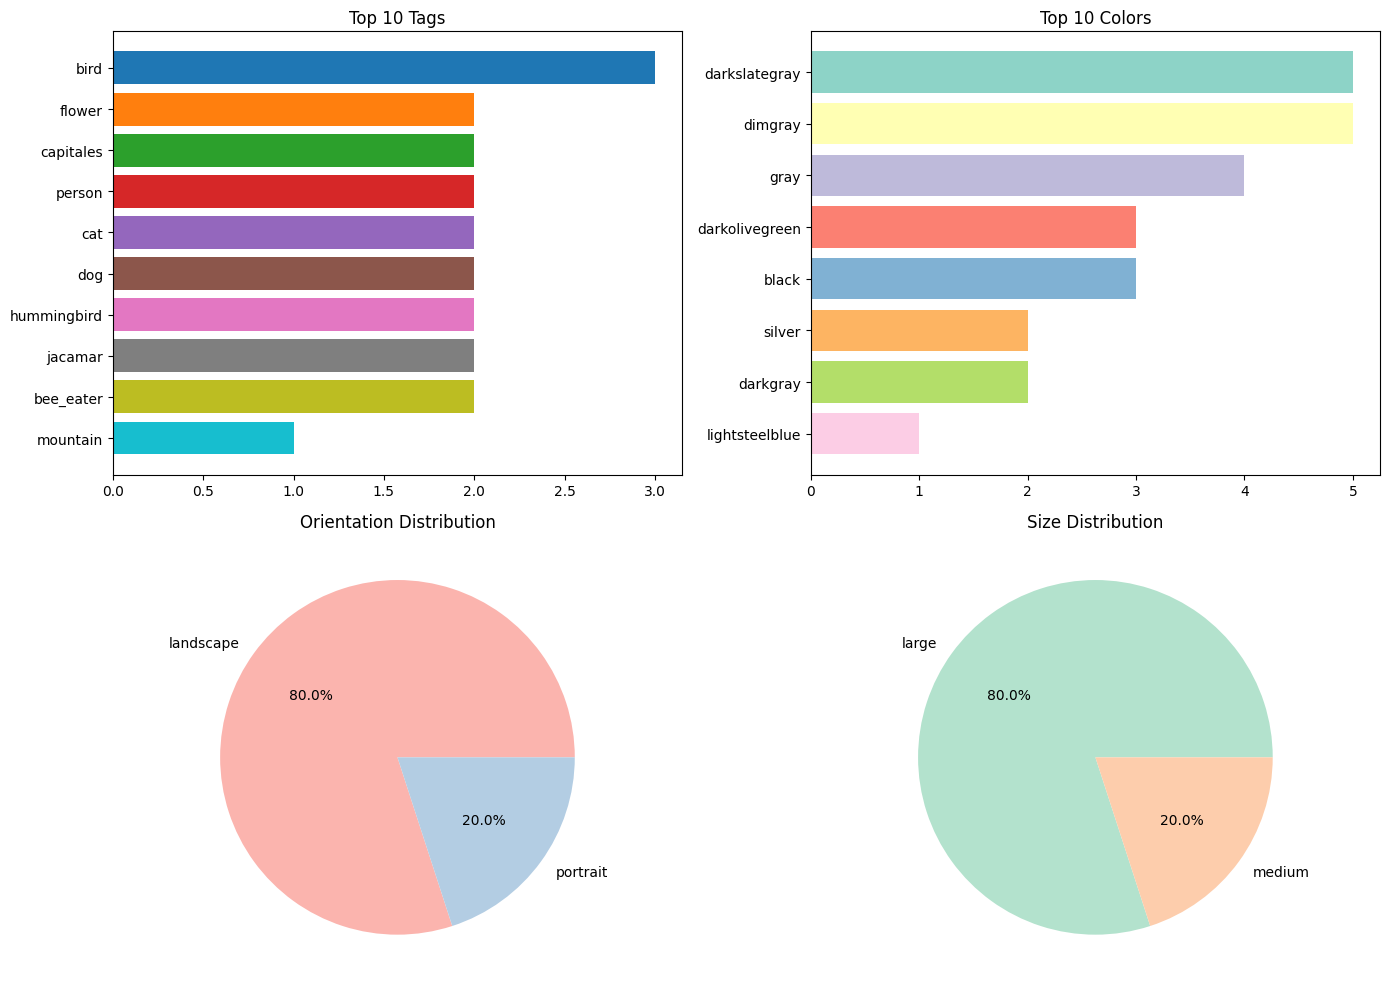


Best number of clusters: 2 (score=0.653)

=== CLUSTERS ===

Cluster 0:
 Users: ['urban_explorer', 'cat_fan', 'bird_watcher']
 Top tags: [('person', 2), ('capitales', 1), ('car', 1), ('palace', 1), ('church', 1)]
 Top colors: [('darkslategray', 3), ('dimgray', 3), ('gray', 3)]

Cluster 1:
 Users: ['nature_lover', 'general_user']
 Top tags: [('flower', 2), ('bird', 2), ('mountain', 1), ('alp', 1), ('valley', 1)]
 Top colors: [('darkolivegreen', 2), ('darkslategray', 2), ('black', 2)]

=== USER PROFILES ===

nature_lover
 Tags: ['mountain', 'flower', 'bird', 'alp', 'valley']
 Colors: ['darkolivegreen', 'darkslategray', 'black', 'dimgray', 'silver']
 Orientation: landscape
 Size: large
 #Images: 20

urban_explorer
 Tags: ['capitales', 'car', 'palace', 'person', 'church']
 Colors: ['darkslategray', 'dimgray', 'darkgray', 'gray', 'lightsteelblue']
 Orientation: landscape
 Size: large
 #Images: 20

cat_fan
 Tags: ['cat', 'Egyptian_cat', 'tabby', 'tiger_cat', 'person']
 Colors: ['darkslategra

In [42]:
# ========================= GLOBAL ANALYSIS =========================

import json
import pandas as pd
from collections import Counter
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import numpy as np
import matplotlib.pyplot as plt

USERS_PATH = "data/users.json"

# =========================
# LOAD USERS (SAFE)
# =========================
try:
    with open(USERS_PATH, "r", encoding="utf-8") as f:
        users = json.load(f)
except:
    print("No valid users.json found")
    users = []

if len(users) == 0:
    print("No users to analyze.")
else:

    # =========================
    # FLATTEN DATA
    # =========================
    all_tags = []
    all_colors = []
    all_orientations = []
    all_sizes = []

    for u in users:
        all_tags.extend(u.get("favorite_tags", []))
        all_colors.extend(u.get("favorite_colors", []))
        all_orientations.append(u.get("favorite_orientation"))
        all_sizes.append(u.get("favorite_size"))

    print("\n================ GLOBAL ANALYSIS ================\n")

    print("Top Tags:")
    print(Counter(all_tags).most_common(10))

    print("\nTop Colors:")
    print(Counter(all_colors).most_common(10))

    print("\nTop Orientations:")
    print(Counter(all_orientations).most_common())

    print("\nTop Sizes:")
    print(Counter(all_sizes).most_common())

    # =========================
    # PANDAS VERSION
    # =========================
    print("\n=== PANDAS ANALYSIS ===")
    print(pd.Series(all_tags).value_counts().head(10))
    print(pd.Series(all_colors).value_counts().head(10))

    # =========================
    # VISUALISATIONS (IMPROVED)
    # =========================
    plt.style.use('default')

    fig, axes = plt.subplots(2, 2, figsize=(14, 10))

    # ---- TAGS ----
    tags_counts = pd.Series(all_tags).value_counts().head(10)
    colors_tags = plt.cm.tab10(range(len(tags_counts)))

    axes[0, 0].barh(tags_counts.index, tags_counts.values, color=colors_tags)
    axes[0, 0].set_title("Top 10 Tags")
    axes[0, 0].invert_yaxis()

    # ---- COLORS ----
    colors_counts = pd.Series(all_colors).value_counts().head(10)
    colors_palette = plt.cm.Set3(range(len(colors_counts)))

    axes[0, 1].barh(colors_counts.index, colors_counts.values, color=colors_palette)
    axes[0, 1].set_title("Top 10 Colors")
    axes[0, 1].invert_yaxis()

    # ---- ORIENTATION ----
    orient_counts = pd.Series(all_orientations).value_counts()
    axes[1, 0].pie(
        orient_counts.values,
        labels=orient_counts.index,
        autopct='%1.1f%%',
        colors=plt.cm.Pastel1.colors
    )
    axes[1, 0].set_title("Orientation Distribution")

    # ---- SIZE ----
    size_counts = pd.Series(all_sizes).value_counts()
    axes[1, 1].pie(
        size_counts.values,
        labels=size_counts.index,
        autopct='%1.1f%%',
        colors=plt.cm.Pastel2.colors
    )
    axes[1, 1].set_title("Size Distribution")

    plt.tight_layout()
    plt.show()

    # =========================
    # CLUSTERING
    # =========================
    def encode_user(u):
        tags = u.get("favorite_tags", [])
        colors = u.get("favorite_colors", [])

        nature = sum(t in ['mountain', 'bird', 'flower', 'cat', 'nature'] for t in tags)
        urban = sum(t in ['city', 'building', 'road'] for t in tags)

        return [
            len(tags),
            len(colors),
            nature,
            urban,
            1 if u.get("favorite_orientation") == "landscape" else 0,
            1 if u.get("favorite_size") == "large" else 0,
        ]

    X = np.array([encode_user(u) for u in users])

    if len(users) >= 3:
        best_k = 2
        best_score = -1

        for k in range(2, min(len(users), 5)):
            kmeans_tmp = KMeans(n_clusters=k, random_state=0, n_init=10)
            labels_tmp = kmeans_tmp.fit_predict(X)
            score = silhouette_score(X, labels_tmp)

            if score > best_score:
                best_k = k
                best_score = score

        print(f"\nBest number of clusters: {best_k} (score={best_score:.3f})")

        kmeans = KMeans(n_clusters=best_k, random_state=0, n_init=10)
        clusters = kmeans.fit_predict(X)

        print("\n=== CLUSTERS ===")
        for cid in range(best_k):
            cluster_users = [u for i, u in enumerate(users) if clusters[i] == cid]

            cluster_tags = []
            cluster_colors = []

            for u in cluster_users:
                cluster_tags.extend(u.get("favorite_tags", []))
                cluster_colors.extend(u.get("favorite_colors", []))

            print(f"\nCluster {cid}:")
            print(" Users:", [u["user_id"] for u in cluster_users])
            print(" Top tags:", Counter(cluster_tags).most_common(5))
            print(" Top colors:", Counter(cluster_colors).most_common(3))

    # =========================
    # USER PROFILES
    # =========================
    print("\n=== USER PROFILES ===")

    for u in users:
        print(f"\n{u['user_id']}")
        print(" Tags:", u.get("favorite_tags", [])[:5])
        print(" Colors:", u.get("favorite_colors", []))
        print(" Orientation:", u.get("favorite_orientation"))
        print(" Size:", u.get("favorite_size"))
        print(" #Images:", len(u.get("favorite_images", [])))